In [ ]:
"""
This is the fourth agent "Conditional Agent"
"""

from typing import TypedDict
from langgraph.graph import StateGraph, START, END
from IPython.display import display, Image

class AgentState(TypedDict):
    number_one: int
    number_two: int
    operation: str
    final_number: int

In [2]:
def addition_node(state: AgentState) -> AgentState:
    """
    Perfroms addition for the Agent and updates the state.
    """

    state["final_number"] = state["number_one"] + state["number_two"]

    return state

def subtraction_node(state: AgentState) -> AgentState:
    """
    Perfroms suntraction for the Agent and updates the state.
    """
    
    state["final_number"] = state["number_one"] - state["number_two"]

    return state


def selection_node(state: AgentState) -> AgentState:
    """
    Decides which opereation to perform based on the 'operation' field in the state.
    """

    if state["operation"] == "+":
        return "addition_node"
    elif state["operation"] == "-":
        return "subtraction_node"
    

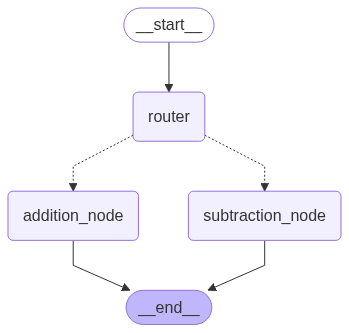

In [4]:
graph = StateGraph(AgentState)
graph.add_node("addition_node", addition_node)
graph.add_node("subtraction_node", subtraction_node)
graph.add_node("router", lambda state:state)

graph.add_edge(START, "router")
graph.add_conditional_edges(
    "router", selection_node,
    {
        "addition_node": "addition_node",
        "subtraction_node": "subtraction_node"
    }
)

graph.add_edge("addition_node", END)
graph.add_edge("subtraction_node", END)

app = graph.compile()

display(Image(app.get_graph().draw_mermaid_png()))


In [6]:
initial_state_1 = AgentState(number_one=5, number_two=8, operation="+")
print(app.invoke(initial_state_1))

initial_state_2 = AgentState(number_one=5, number_two=8, operation="-")
print(app.invoke(initial_state_2))

{'number_one': 5, 'number_two': 8, 'operation': '+', 'final_number': 13}
{'number_one': 5, 'number_two': 8, 'operation': '-', 'final_number': -3}
